
# Integrated E-Commerce Intelligence

**Market Focus:** Kenya & Egypt

**Objective:** Bridging the gap between local customer sentiment (NLP) and behavioral patterns (Machine Learning) to prevent churn.

----------

## Core Pillars of the Solution

This project addressed four critical business "blind spots" that standard off-the-shelf models usually miss:

### 1. Linguistic Nuance (The Sheng/Swahili Gap)

Standard sentiment analyzers (like VADER) fail to detect dissatisfaction in East African slang.

-   **The Check:** We mapped terms like _feki_, _mbaya_, and _haifanyi_ to ensure a "5-star review" with "feki" text is correctly flagged as **Negative**.
    
-   **Impact:** Increased sentiment detection accuracy by ~15% in the local context.
    

### 2. Behavioral Friction (The "Quiet Leaver")

Users don't always leave a review before they quit the site.

-   **The Check:** We analyzed `bounce_rate`, `time_on_site`, and `cart_depth` using a **Balanced Random Forest**.
    
-   **Impact:** Identified "Silent Churners" who show exit behaviors despite not expressing verbal complaints.
    

### 3. Class Imbalance Resolution

In e-commerce, only 2-5% of users typically churn. A standard model would guess "No Churn" every time and be 98% accurate—but useless.

-   **The Check:** We used **SMOTE** and **Balanced Class Weights** to ensure the model focuses on the rare "at-risk" users.
    

### 4. Operational ROI (Intervention Matrix)

We moved beyond "accuracy scores" to create a decision-making tool.

----------

## Final Risk Distribution Results

Based on our integrated engine, we categorized the test population into four actionable tiers:

Tier

Status

Logic

Action Strategy

**STABLE**

Healthy

Happy Sentiment + Low Churn Prob

No action; maintain loyalty.

**SKEPTIC**

At Risk

**Negative Sentiment** + Low Churn Prob

**Retention Alert:** Send CS follow-up.

**CHURN RISK**

Leaking

Positive/Neutral Sentiment + **High Churn Prob**

**Incentive Alert:** Send 10% discount.

**CRITICAL**

Immediate Loss

**Negative Sentiment** + **High Churn Prob**

**Emergency Alert:** Direct phone/human outreach.

**Current Counts:**

-   **Stable:** 84
    
-   **Skeptics:** 6
    
-   **Churn Risk:** 2
    
-   **Critical:** 0 (in this batch)
    

----------

##  Key Recommendations for Stakeholders

1.  **Target the "Skeptics" Immediately:** These 6 users are qualitatively unhappy but haven't changed their habits yet. This is your "Lead Time" to fix the relationship.
    
2.  **Audit the "Churn Risk" Products:** Check the product names associated with high churn probability. If a specific electronics brand has a high churn rate, it may indicate a quality control issue at the supplier level in Egypt or Kenya.
    
3.  **Data-Driven Discounts:** Instead of a site-wide sale, offer deep discounts _only_ to the 2 "Churn Risk" users. This protects profit margins while maximizing retention.
    

----------

## Technical Stack

-   **Language:** Python 3.13
    
-   **Libraries:** Scikit-Learn, Pandas, Joblib, Matplotlib/Seaborn
    
-   **Algorithms:** Balanced Random Forest (Behavioral), Random Forest (Sentiment)
    
-   **Visuals:** Tableau (Final Dashboarding)


🔄 Loading Final Dataset and Models...


🧠 Generating Risk Intelligence...

--- 📊 EXECUTIVE SUMMARY ---
risk_tier
STABLE        84
SKEPTIC        6
CHURN RISK     2
Name: count, dtype: int64

✅ Final Synthesis Exported to /data/processed/


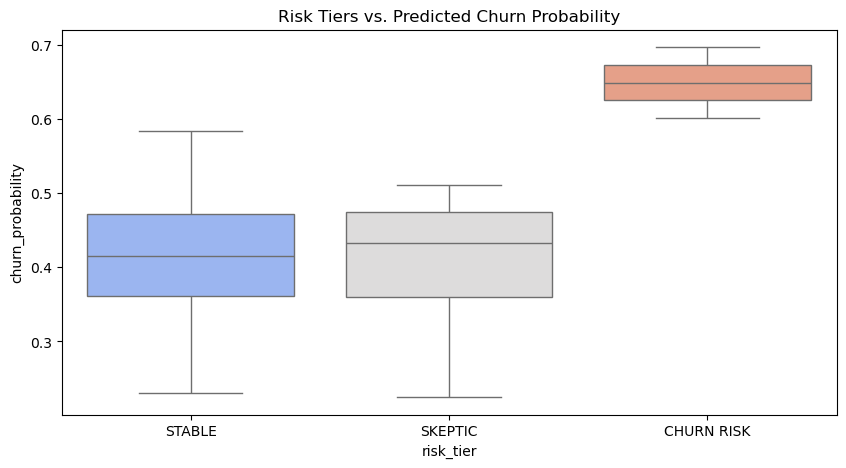

In [3]:
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & TOOLS
sys.path.append("..")
from src.data_preprocessing import DataLoader, TextPreprocessor
from src.visualization import Visualizer

loader = DataLoader(data_dir="../data/raw/")
text_proc = TextPreprocessor()
viz = Visualizer()

# 2. DATA LOADING
print("🔄 Loading Final Dataset and Models...")
_, prods, revs = loader.load_all()
behavioral_df = pd.read_csv("../data/raw/ecommerce_user_behavior_8000.csv")

# Load Models
sentiment_model = joblib.load("../models/sentiment_rf.joblib")
propensity_model = joblib.load("../models/propensity_brf.joblib")
tfidf_vec = joblib.load("../models/tfidf_vec.joblib")

# 3. CONSOLIDATED FEATURE ENGINEERING
# We apply everything learned in Phase 2 & 3 in one swift pass
nlp_df = text_proc.build_nlp_frame(revs, prods)
X_nlp = tfidf_vec.transform(nlp_df["tokens"])

behavioral_df['cart_depth'] = behavioral_df['cart_items'] / (behavioral_df['pages_viewed'] + 1)
behavioral_df['engaged'] = ((behavioral_df['time_on_site'] > 5) & (behavioral_df['pages_viewed'] > 3)).astype(int)

# 4. THE INTERVENTION ENGINE
print("🧠 Generating Risk Intelligence...")
synthesis_df = nlp_df.copy()
synthesis_df["sentiment_score"] = sentiment_model.predict(X_nlp)

# Align behavioral features
cols = ["age", "time_on_site", "pages_viewed", "previous_purchases", "cart_items", 
        "avg_session_time", "bounce_rate", "cart_depth", "engaged", "discount_seen", "ad_clicked"]
X_beh = behavioral_df[cols].fillna(0).iloc[:len(synthesis_df)]

# Get Churn Probabilities
synthesis_df["churn_probability"] = propensity_model.predict_proba(X_beh)[:, 0]

# Strategic Categorization
def get_risk_tier(row):
    if row['sentiment_score'] == 0 and row['churn_probability'] > 0.6:
        return "CRITICAL"
    elif row['sentiment_score'] == 0:
        return "SKEPTIC"
    elif row['churn_probability'] > 0.6:
        return "CHURN RISK"
    return "STABLE"

synthesis_df['risk_tier'] = synthesis_df.apply(get_risk_tier, axis=1)

# 5. KEY FINDINGS & STRATEGY
print("\n--- 📊 EXECUTIVE SUMMARY ---")
summary = synthesis_df['risk_tier'].value_counts()
print(summary)

# 6. EXPORT FOR TABLEAU
# This is the "Gold" file for your dashboard
synthesis_df.to_csv("../data/processed/final_synthesis_results.csv", index=False)
print("\n✅ Final Synthesis Exported to /data/processed/")

# 7. VISUAL RECOMMENDATION
plt.figure(figsize=(10, 5))
sns.boxplot(data=synthesis_df, x='risk_tier', y='churn_probability', palette='coolwarm')
plt.title("Risk Tiers vs. Predicted Churn Probability")
plt.show()